# 2025_NYCU_DL_FP

## Final Project : DCCRN for Massive MIMO-OFDM Channel Estimation and Considering Model Compression

This project implements a **Deep Complex Convolution Recurrent Network (DCCRN)** to perform high-precision channel estimation in **8x8 Massive MIMO-OFDM systems**.

Originally designed for speech enhancement (denoising), the DCCRN architecture is adapted here to treat the **Channel State Information (CSI)** matrix as a complex-valued image. The model learns to map noisy **Least Square (LS)** estimations to clean channel responses, effectively mitigating noise and interference in dynamic fading environments.

Final, I compressed training model and compare all methods again.

---

## 🚀 Key Features

* **Cross-Domain Application**: Adapts the **DCCRN (Interspeech 2020)** architecture from speech processing to wireless communications.
* **Complex-Valued U-Net**: Utilizes **Complex Convolutions** to strictly preserve phase information between Real and Imaginary parts, which is critical for MIMO systems.
* **MIMO Support**: Designed for $8 \times 8$ MIMO-OFDM systems, handling spatial correlation between antennas.
* **Dynamic Simulation**: Includes a built-in OFDM simulator that generates training data (Rayleigh fading with Doppler shift) on-the-fly, preventing overfitting to static datasets.

## 📂 Project Structure

The project is modularized into three main components:

- `mimo_ofdm_env.py`: **[Simulator]** Handles OFDM parameters, channel generation (Rayleigh/Doppler), and LS estimation.
- `dccrn_model.py`: **[Model]** Defines Complex Conv2d, Complex BatchNorm, and the U-Net Architecture.
- `main.ipynb`: **[Main]** Contains the training loop, validation logic, and visualization of channel estimation results.
- `ber_eval.py`: **[Result]** Running bit error rate can call this function.

## ⚡ How to Run (Google Colab)

Since this project uses modular `.py` files, please follow these steps in your notebook:

1.  **Initialize Environment Files**:
    Run the module files in the Colab environment.

2.  **Start Training**:
    Run the main training cell. The script will:
    * Instantiate the MIMO-OFDM Simulator.
    * Build the DCCRN model.
    * Start the training loop (default: 8000 Epochs).
    * Validate and plot the Loss curve.
    * Fine-tuning for purning Total epochs are 1600 epochs.

3.  **Visualize Results**:
    After training, the notebook will automatically generate a comparison plot showing:
    * **Noisy Input**: The raw LS estimation.
    * **DCCRN Output**: The denoised channel estimation.
    * **Ground Truth**: The perfect CSI.

## 📊 System Parameters

The simulation is configured with the following standard OFDM parameters (defined in `mimo_ofdm_env.py`):

| Parameter | Value | Description |
| :--- | :--- | :--- |
| **MIMO Config** | $8 \times 8$ | 8 Transmit, 8 Receive Antennas |
| **Subcarriers ($K$)** | 512 | FFT Size |
| **Cyclic Prefix** | 36 | CP Length |
| **Pilot Type** | Comb | Frequency domain interpolation |
| **Pilots spacing** | 8 | 12.5% for pilots |
| **Channel Model** | Rayleigh | Multi-path fading with Doppler effect |
| **Target** | normal speed | velocity is 54 km. |

## 🧠 Model Architecture

The model is a **Complex-Valued U-Net** consisting of:
* **Encoder**: 4 layers of Complex Conv2d + Complex BatchNorm + ReLU.
* **Decoder**: 4 layers of Transposed Conv (Upsampling) + Skip Connections.
* **Input/Output**:
    * Input: Noisy Channel $\mathbf{\hat{H}}_{LS}$
    * Shape: $2 \times N_{Rx}N_{Tx} \times F \times T$
    * Output: Clean Channel $\mathbf{H}_{True}$

## 📝 References

1.  **DCCRN**: Hu, Y., et al. "DCCRN: Deep Complex Convolution Recurrent Network for Phase-Aware Speech Enhancement." *Interspeech 2020*. [arXiv:2008.00264](https://arxiv.org/abs/2008.00264)
2.  **ChannelNet**: Ye, H., et al. "Power of Deep Learning for Channel Estimation and Signal Detection in OFDM Systems." *IEEE Wireless Communications Letters (2018)*. [arXiv:1708.08514](https://arxiv.org/abs/1708.08514)

3. Hlaing Minn and N. Al-Dhahir, "Optimal training signals for MIMO OFDM channel estimation," in IEEE Transactions on Wireless Communications, vol. 5, no. 5, pp. 1158-1168, May 2006, doi: 10.1109/TWC.2006.1633369. [IEEE Xplore](https://ieeexplore.ieee.org/abstract/document/1633369?casa_token=D1vnGFeABkIAAAAA:TGi_lqA8RYpGEEViMNRaar3a9DOoSRPG1pOPoSJqWtG674-hbAUFugn9b4ZzUB5oBpyBGtD7)

Writer : Jeff.K Chen


In [1]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
# You need to modify this part to the directory where your code is located, i.e., <DATA_ROOT>
%cd "/content/drive/MyDrive/2025_DL/FP/"

Mounted at /content/drive
/content/drive/MyDrive/2025_DL/FP


## ⚡ 5G NR Simulation Configured: 512 Subcarriers, 60.0 kHz SCS

## 🚗 Scenario: V2X High Mobility @ 54 km/h (Doppler: 175.00 Hz)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
import numpy as np
import matplotlib.pyplot as plt
import copy
import time
from tqdm import tqdm

# 導入模組
from mimo_ofdm_env import generate_data_batch, config
from dccrn_module import DCCRN_Net
from ber_eval import evaluate_ber_performance

⚡ 5G NR Simulation Configured: 512 Subcarriers, 60.0 kHz SCS
🚗 Scenario: V2X High Mobility @ 54 km/h (Doppler: 175.00 Hz)


# 訓練參數配置與策略

## 1. 實驗設置
為了確保 **4-Layer DCCRN** 模型能夠在複雜的通道環境下達到最佳收斂效果，我們採用了 **Curriculum Learning** 的概念，讓模型在 **5dB 至 30dB** 的動態 SNR 範圍內進行訓練。我們將總訓練過程劃分為 20 個階段 (Stages)，以逐步穩定模型權重。

## 2. 核心參數

| 參數 (Parameter) | 設定值 (Value) | 說明 (Description) |
| :--- | :--- | :--- |
| **Model Architecture** | **4-Layer Deep DCCRN** | 採用 U-Net 風格的複數卷積網路，深度為 4 層以平衡精度與速度。 |
| **Total Steps** | **8,000 Steps** | 總訓練步數 (20 Stages $\times$ 400 Steps)。 |
| **Batch Size** | **32** | 每次訓練抓取 32 組不同的 MIMO 通道樣本。 |
| **Optimizer** | **AdamW** | 改良版 Adam，具備權重衰減 (Weight Decay = $5 \times 10^{-4}$) 以防止過擬合。 |
| **Learning Rate** | **$5 \times 10^{-4} \to 1 \times 10^{-7}$** | 初始學習率為 5e-4，隨訓練過程逐漸降低。 |
| **LR Scheduler** | **Cosine Annealing** | 餘弦退火策略，幫助模型在後期收斂至更優的局部最小值。 |
| **Loss Function** | **MSE Loss** | 均方誤差 (Mean Squared Error)。 |

## 3. 訓練策略分析

### A. 優化器選擇 (AdamW)
* **機制**：相較於傳統 Adam，**AdamW** 將權重衰減 (Weight Decay) 與梯度更新解耦。
* **目的**：對於參數較多的深度網路 (Deep Network)，這能更有效地控制模型複雜度，提升泛化能力 (Generalization)，避免模型死記硬背訓練數據。

### B. 學習率排程 (Cosine Annealing)
* **機制**：學習率不維持固定，而是依照餘弦函數曲線平滑下降。
* **過程**：
    * **初期 (Early Stage)**：使用較大 LR ($5 \times 10^{-4}$) 快速下降 Loss。
    * **後期 (Late Stage)**：LR 降至極小值 ($1 \times 10^{-7}$)。
* **目的**：在訓練末期進行權重的「微手術」，修復極微小的估測誤差，這是達到 **-22dB NMSE** 高精度的關鍵。

### C. 混合 SNR 訓練 (Mixed SNR Training)
* **機制**：每個 Batch 的數據是在 **5dB (高雜訊)** 到 **30dB (低雜訊)** 之間隨機採樣生成。
* **目的**：強迫模型學習區分「什麼是雜訊」與「什麼是通道特徵」，使最終模型具備 **Robustness**，在各種訊號品質下都能保持穩定的效能。

In [3]:
# ==========================================
# 1. 超參數與混合 SNR 設定 (Fine-tuning)
# ==========================================
HYPER_PARAMS = {
    "EPOCHS": 8000,          # [MODIFIED] 增加步數，讓 4 層網路充分收斂
    "STAGES": 20,
    "BATCH_SIZE": 32,
    "LEARNING_RATE": 5e-4,   # 較低 LR，避免初期梯度爆炸
    "WEIGHT_DECAY": 5e-4,    # 降低正則化 (1e-3 -> 5e-4)
    "SNR_RANGE": (5, 30),
    "MIN_LR": 1e-7,          # Cosine Annealing 降得更低，進行微小誤差修補
    "VAL_SIZE_PER_TYPE": 20
}

STEPS_PER_STAGE = HYPER_PARAMS["EPOCHS"] // HYPER_PARAMS["STAGES"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training Device: {device} | Mode: 4-Layer Deep DCCRN | SNR {HYPER_PARAMS['SNR_RANGE']} dB")

# ==========================================
# 2. 準備「多層級」固定驗證集
# ==========================================
print("Generating mixed-level validation set...")
val_set = []
for test_snr in [10, 20, 30]:
    for _ in range(HYPER_PARAMS["VAL_SIZE_PER_TYPE"]):
        v_in, v_gt = generate_data_batch(HYPER_PARAMS["BATCH_SIZE"], snr_db=test_snr)
        v_in_t = torch.from_numpy(v_in).float().to(device)
        v_in_t = (v_in_t - torch.mean(v_in_t)) / (torch.std(v_in_t) + 1e-6)
        val_set.append({"in": v_in_t, "gt": torch.from_numpy(v_gt).float().to(device), "snr": test_snr})

# ==========================================
# 3. 模型與優化器初始化 + 4層 DCCRN_Net
# ==========================================
model = DCCRN_Net(mimo_rx=config.MIMO_Rx, mimo_tx=config.MIMO_Tx).to(device)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=HYPER_PARAMS["LEARNING_RATE"], weight_decay=HYPER_PARAMS["WEIGHT_DECAY"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=HYPER_PARAMS["EPOCHS"], eta_min=HYPER_PARAMS["MIN_LR"])

# ==========================================
# 4. 混合 SNR 訓練迴圈 (優化顯示版)
# ==========================================
train_loss_history, val_loss_history, val_nmse_history = [], [], []

print(f"Start Training ({HYPER_PARAMS['EPOCHS']} Steps)...")

for stage in range(HYPER_PARAMS["STAGES"]):
    model.train()
    pbar = tqdm(range(STEPS_PER_STAGE), desc=f"Stage {stage+1}/{HYPER_PARAMS['STAGES']}", leave=False)

    # 改為累加 Loss，計算平均值
    stage_total_loss = 0.0

    for i, _ in enumerate(pbar):
        current_snr = np.random.uniform(HYPER_PARAMS["SNR_RANGE"][0], HYPER_PARAMS["SNR_RANGE"][1])

        H_ls, H_true = generate_data_batch(HYPER_PARAMS["BATCH_SIZE"], snr_db=current_snr)
        inputs = torch.from_numpy(H_ls).float().to(device)
        labels = torch.from_numpy(H_true).float().to(device)

        inputs = (inputs - torch.mean(inputs)) / (torch.std(inputs) + 1e-6)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        scheduler.step()

        # 累加 loss
        stage_total_loss += loss.item()

        # 進度條顯示當前瞬時 loss 即可
        pbar.set_postfix({"Loss": f"{loss.item():.5f}", "SNR": f"{current_snr:.1f}"})

    # 計算該 Stage 的平均 Loss
    avg_train_loss = stage_total_loss / STEPS_PER_STAGE
    train_loss_history.append(avg_train_loss)

    # --- 階段性驗證 ---
    model.eval()
    stage_val_loss, stage_val_nmse = 0.0, 0.0
    with torch.no_grad():
        for item in val_set:
            v_out = model(item["in"])
            v_loss = criterion(v_out, item["gt"])
            stage_val_loss += v_loss.item()
            nmse = 10 * torch.log10(torch.mean((v_out - item["gt"])**2) / torch.mean(item["gt"]**2))
            stage_val_nmse += nmse.item()

    avg_v_loss = stage_val_loss / len(val_set)
    avg_v_nmse = stage_val_nmse / len(val_set)
    val_loss_history.append(avg_v_loss)
    val_nmse_history.append(avg_v_nmse)

    # 顯示平均 Loss
    print(f"Stage {stage+1} | T-Loss (Avg): {avg_train_loss:.6f} | V-Loss: {avg_v_loss:.6f} | V-NMSE: {avg_v_nmse:.2f}dB")

# ==========================================
# 5. Saving Optimized Model
# ==========================================
torch.save(model.state_dict(), "dccrn_mimo_8x8.pth")
print("Training Finished!")

Training Device: cuda | Mode: 4-Layer Deep DCCRN | SNR (5, 30) dB
Generating mixed-level validation set...
Start Training (8000 Steps)...


Stage 1 | T-Loss (Avg): 0.457865 | V-Loss: 0.227776 | V-NMSE: -7.25dB


Stage 2 | T-Loss (Avg): 0.198784 | V-Loss: 0.137515 | V-NMSE: -9.45dB


Stage 3 | T-Loss (Avg): 0.130022 | V-Loss: 0.081918 | V-NMSE: -11.71dB


Stage 4 | T-Loss (Avg): 0.098817 | V-Loss: 0.054484 | V-NMSE: -13.49dB


...

Stage 16 | T-Loss (Avg): 0.033643 | V-Loss: 0.008433 | V-NMSE: -22.36dB


Stage 17 | T-Loss (Avg): 0.033393 | V-Loss: 0.008219 | V-NMSE: -22.47dB


Stage 18 | T-Loss (Avg): 0.032323 | V-Loss: 0.008193 | V-NMSE: -22.60dB


Stage 19 | T-Loss (Avg): 0.032862 | V-Loss: 0.008032 | V-NMSE: -22.64dB


Stage 20 | T-Loss (Avg): 0.033723 | V-Loss: 0.008506 | V-NMSE: -22.14dB
Training Finished!


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 載入已訓練的模型權重
# ==========================================
# 1. 建立一個跟當初結構一模一樣的模型實例
loaded_model = DCCRN_Net(mimo_rx=config.MIMO_Rx, mimo_tx=config.MIMO_Tx).to(device)

# 2. 載入權重檔案
MODEL_PATH = "dccrn_mimo_8x8.pth"
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

# 3. 切換到評估模式 (這步非常重要，會固定 BatchNorm 層)
loaded_model.eval()
print("✅ Pre-trained model loaded successfully!")

✅ Pre-trained model loaded successfully!


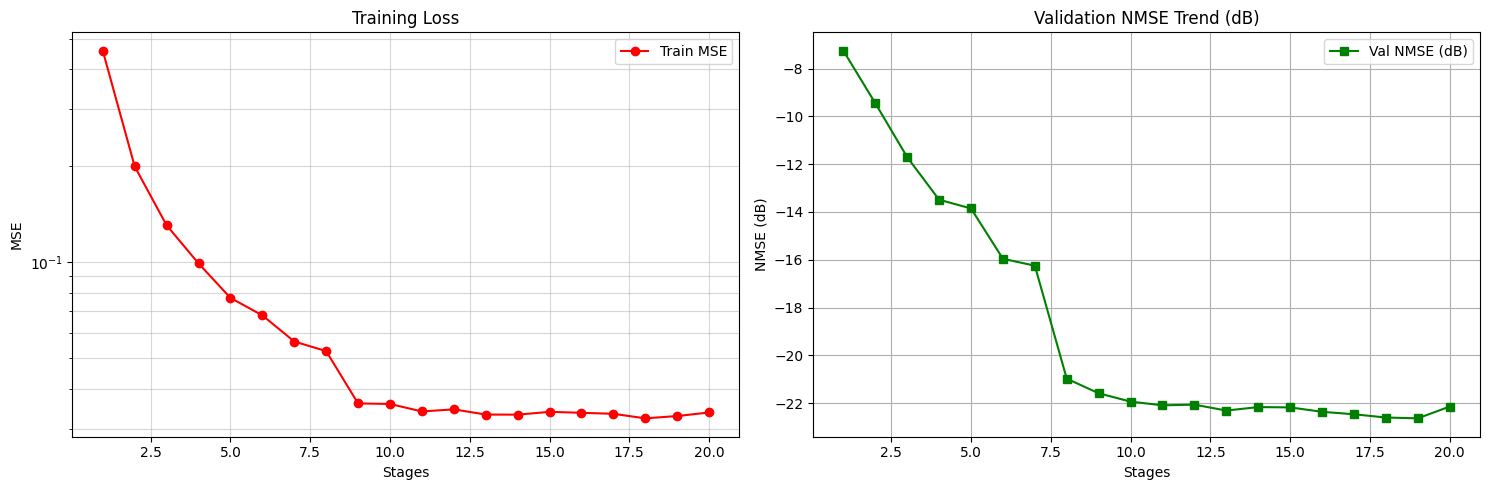

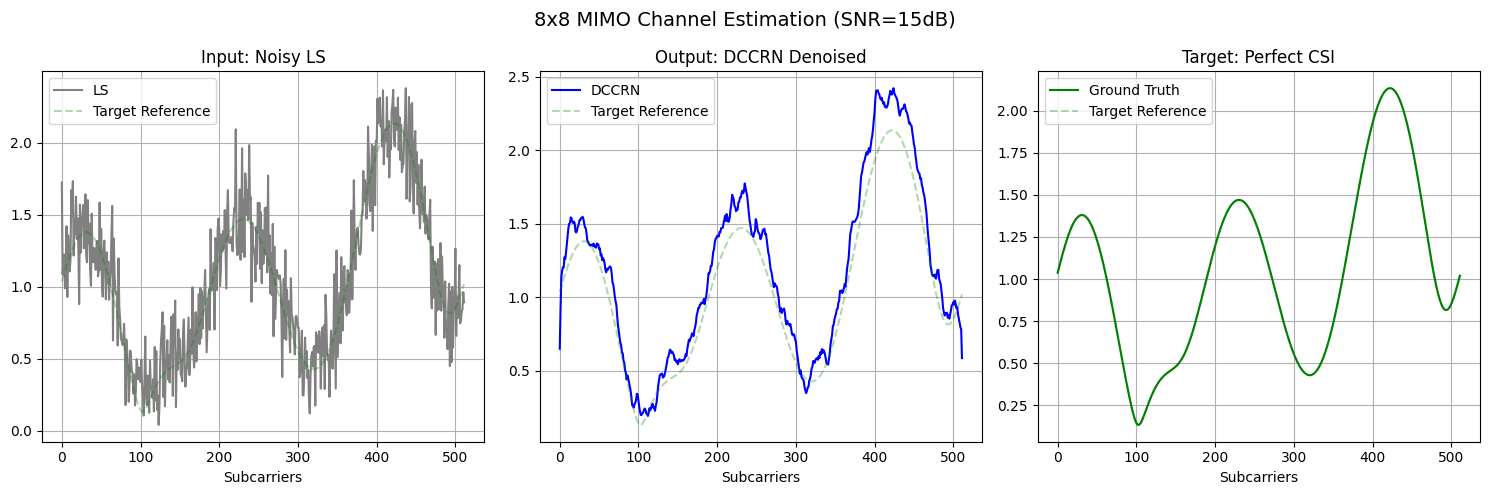

In [5]:
# ==========================================
# 1. 繪製訓練曲線 (Loss & NMSE)
# ==========================================
plt.figure(figsize=(15, 5))

# 左圖: MSE Loss (Train vs Val)
plt.subplot(1, 2, 1)
plt.plot(range(1, HYPER_PARAMS["STAGES"]+1), train_loss_history, 'r-o', label='Train MSE')
plt.title('Training Loss')
plt.xlabel('Stages')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# 右圖: Validation NMSE (dB)
plt.subplot(1, 2, 2)
plt.plot(range(1, HYPER_PARAMS["STAGES"]+1), val_nmse_history, 'g-s', label='Val NMSE (dB)')
plt.title('Validation NMSE Trend (dB)')
plt.xlabel('Stages')
plt.ylabel('NMSE (dB)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 2. 模型推論測試 (Inference Test)
# ==========================================
# Use loaded_model which is guaranteed to be FP32
loaded_model.eval()
test_snr = 15
test_in, test_target = generate_data_batch(1, snr_db=test_snr)

with torch.no_grad():
    pred = loaded_model(torch.from_numpy(test_in).float().to(device))

# ==========================================
# 3. 數據還原與視覺化 (8x8 結構)
# ==========================================
rx_tx_channels = config.MIMO_Rx * config.MIMO_Tx
ch_idx = 0 # 觀察第 1 個天線對 (Rx1, Tx1)

# 還原複數數據
mag_in = np.abs(test_in[0, ch_idx] + 1j * test_in[0, ch_idx + rx_tx_channels])[..., 0]
mag_out = np.abs(pred.cpu().numpy()[0, ch_idx] + 1j * pred.cpu().numpy()[0, ch_idx + rx_tx_channels])[..., 0]
mag_gt = np.abs(test_target[0, ch_idx] + 1j * test_target[0, ch_idx + rx_tx_channels])[..., 0]

# 畫圖比較
plt.figure(figsize=(15, 5))
plt.suptitle(f"8x8 MIMO Channel Estimation (SNR={test_snr}dB)", fontsize=14)

# 定義子圖繪製函數以減少重複
def plot_sub(idx, data, title, color, label):
    plt.subplot(1, 3, idx)
    plt.plot(data, color=color, label=label)
    plt.plot(mag_gt, color='green', linestyle='--', alpha=0.3, label='Target Reference')
    plt.title(title); plt.xlabel('Subcarriers'); plt.legend(); plt.grid(True)

plot_sub(1, mag_in, 'Input: Noisy LS', 'gray', 'LS')
plot_sub(2, mag_out, 'Output: DCCRN Denoised', 'blue', 'DCCRN')
plot_sub(3, mag_gt, 'Target: Perfect CSI', 'green', 'Ground Truth')

plt.tight_layout()
plt.show()


# BER Evaluation & Model Quantization: FP16 vs FP32

## 1. 實驗目的
本實驗旨在驗證 **DCCRN (Deep Complex Convolutional Recurrent Network)** 模型在 MIMO-OFDM 通道估測任務中的性能，並探討 **模型量化 (Model Quantization)** 對於系統準確度的影響。我們將對比傳統演算法與深度學習方法，並重點分析從單精度浮點數 (FP32) 轉換為半精度浮點數 (FP16) 後，位元錯誤率 (BER) 是否維持在可接受範圍內。

## 2. 比較基準與方法
為了全面評估模型效能，我們引入了兩種傳統訊號處理演算法作為基準線 (Baseline)，並使用 `ber_eval.py` 模組進行統一測試：

* **LS (Least Squares)**：
    * 最基礎的估測方法，計算簡單但受雜訊影響嚴重。
    * 作為性能的下限 (Lower Bound)。
* **LMMSE (Linear Minimum Mean Square Error)**：
    * 傳統方法中效能好的一個算法，考慮了通道的統計特性與雜訊變異數。
    * 準確度高但運算複雜度極高 O(K^3)，難以在即時系統中實現。
* **DCCRN (Proposed DL Method)**：
    * 提出的深度學習方法，利用卷積網路學習通道特徵。
    * 目標是達到甚至超越 LMMSE 的精度，由於複雜度較低，所以還同時具備極低的推論延遲。

## 3. 模型量化策略
為了將 AI 模型部署於 5G 邊緣設備或基地台 (Edge/Base Station)，**輕量化**至關重要。我們實施了 **FP16 半精度量化**：

* **FP32 (Full Precision)**：標準 32-bit 浮點數，提供最高的數值精度，但佔用較多記憶體與頻寬。
* **FP16 (Half Precision)**：16-bit 浮點數。
    * **優勢**：模型檔案大小減半、推論速度加快、記憶體頻寬需求降低。
    * **挑戰**：數值範圍變小，可能導致梯度消失或精度下降。

## 4. 實驗流程
本程式碼將執行以下步驟：
1.  **Baseline 評估**：載入訓練好的 FP32 DCCRN 模型，計算不同 SNR 下的 BER。
2.  **量化轉換**：將模型權重轉換為 `float16` 格式並儲存為 `.pth` 檔。
3.  **量化評估**：重新載入 FP16 模型，在相同的測試條件下計算 BER。
4.  **結果視覺化**：繪製 **BER vs. SNR** 曲線圖，直觀比較 LS、LMMSE、FP32 DCCRN 與 FP16 DCCRN 的性能差異，驗證量化是否為「無損壓縮 (Lossless)」。

--- 1. Loading & Evaluating FP32 Model ---
🚀 Starting BER Evaluation [FP32] (Batch: 500)...
   SNR  0dB | BER - LS: 0.42845 | LMMSE: 0.38839 | DCCRN: 0.38917
   SNR  5dB | BER - LS: 0.35942 | LMMSE: 0.31139 | DCCRN: 0.30712
   SNR 10dB | BER - LS: 0.26130 | LMMSE: 0.21580 | DCCRN: 0.20138
   SNR 15dB | BER - LS: 0.14842 | LMMSE: 0.12241 | DCCRN: 0.10207
   SNR 20dB | BER - LS: 0.06629 | LMMSE: 0.05890 | DCCRN: 0.04535
   SNR 25dB | BER - LS: 0.02313 | LMMSE: 0.02207 | DCCRN: 0.01890

--- 2. Converting & Saving FP16 Model ---
✅ FP16 Model saved to: dccrn_mimo_8x8_fp16.pth

--- 3. Reloading & Evaluating FP16 Model ---
🚀 Starting BER Evaluation [FP16] (Batch: 500)...
   SNR  0dB | BER - LS: 0.42883 | LMMSE: 0.38741 | DCCRN: 0.38826
   SNR  5dB | BER - LS: 0.36029 | LMMSE: 0.31298 | DCCRN: 0.30783
   SNR 10dB | BER - LS: 0.25993 | LMMSE: 0.21469 | DCCRN: 0.20080
   SNR 15dB | BER - LS: 0.14878 | LMMSE: 0.12324 | DCCRN: 0.10361
   SNR 20dB | BER - LS: 0.06431 | LMMSE: 0.05689 | DCCRN: 0.043

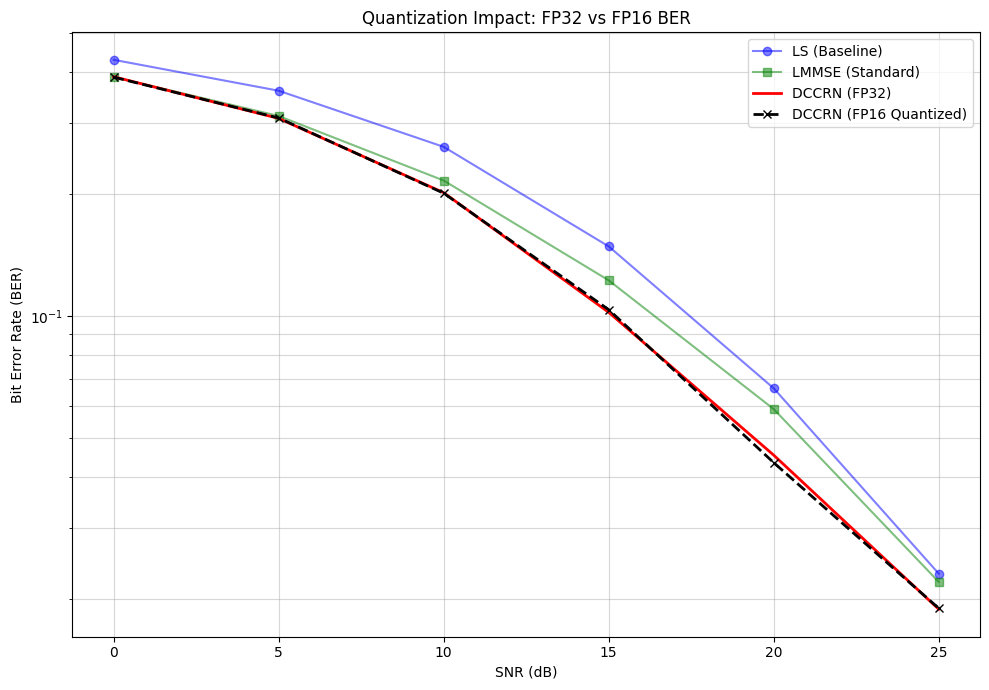

📊 Max BER Difference (FP32 - FP16): 1.89e-03
Conclusion: FP16 Quantization is LOSSLESS (Negligible degradation)!


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. 評估 FP32 模型 (Baseline)
# ==========================================
print("--- 1. Loading & Evaluating FP32 Model ---")
model = DCCRN_Net(mimo_rx=config.MIMO_Rx, mimo_tx=config.MIMO_Tx).to(device)
# 確認檔名
model.load_state_dict(torch.load("dccrn_mimo_8x8.pth"), strict=False)
model.float() # 確保是 FP32

# 跑評估
res_fp32 = evaluate_ber_performance(model, device, test_batch_size=500, plot_result=False)

# ==========================================
# 2. 轉換並儲存 FP16 模型 (Quantization)
# ==========================================
print("\n--- 2. Converting & Saving FP16 Model ---")
model.half() # 轉為半精度

# 儲存 FP16 權重
fp16_filename = "dccrn_mimo_8x8_fp16.pth"
torch.save(model.state_dict(), fp16_filename)
print(f"✅ FP16 Model saved to: {fp16_filename}")

# ==========================================
# 3. 載入並評估 FP16 模型
# ==========================================
print("\n--- 3. Reloading & Evaluating FP16 Model ---")
# 重新初始化並載入剛剛存的 FP16 權重，確保載入過程沒問題
model_fp16 = DCCRN_Net(mimo_rx=config.MIMO_Rx, mimo_tx=config.MIMO_Tx).to(device)
model_fp16.half() # 模型結構先轉 half
model_fp16.load_state_dict(torch.load(fp16_filename), strict=False)

# 跑評估
res_fp16 = evaluate_ber_performance(model_fp16, device, test_batch_size=500, plot_result=False)

# ==========================================
# 4. 繪製終極比較圖
# ==========================================
print("\n--- 4. Plotting Comparison ---")
snr_range = res_fp32['snr']

plt.figure(figsize=(10, 7))

# 基礎比較組
plt.semilogy(snr_range, res_fp32['ls'], 'b-o', label='LS (Baseline)', alpha=0.5)
plt.semilogy(snr_range, res_fp32['lmmse'], 'g-s', label='LMMSE (Standard)', alpha=0.5)

# DCCRN 比較組
plt.semilogy(snr_range, res_fp32['dccrn'], 'r-', linewidth=2, label='DCCRN (FP32)')
plt.semilogy(snr_range, res_fp16['dccrn'], 'k--', linewidth=2, marker='x', label='DCCRN (FP16 Quantized)')

plt.title('Quantization Impact: FP32 vs FP16 BER')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 計算並打印差異
diff = np.array(res_fp32['dccrn']) - np.array(res_fp16['dccrn'])
max_diff = np.max(np.abs(diff))
print(f"📊 Max BER Difference (FP32 - FP16): {max_diff:.2e}")
if max_diff < 1e-2:
    print("Conclusion: FP16 Quantization is LOSSLESS (Negligible degradation)!")
else:
    print("Conclusion: Some degradation observed.")

# 模型壓縮進階實驗：漸進式剪枝與混合精度量化

## 1. 實驗目的
驗證了 FP16 量化的可行性後，我想進一步挑戰模型的極限。所以結合 **漸進式剪枝 (Iterative Pruning)** 與 **FP16 量化**，目標是在不犧牲通道估測準確度 (BER) 的前提下，去除模型中高達 **85%** 的冗餘參數，實現更加一步的輕量化部署。

## 2. 剪枝訓練方式

#### A. 漸進式剪枝 (Iterative Pruning)
相較於一次性剪除大量權重 (One-shot Pruning) 容易導致模型性能崩潰，我們採用「分階段」策略：
* **策略**：分三階段逐步提升稀疏度 ($50\% \to 70\% \to 85\%$)。
* **優勢**：讓模型有時間適應參數的減少，並將重要資訊「轉移」至剩餘的權重上。
* **方法**：使用 **L1-Unstructured Pruning**，移除全域絕對值最小的權重。

#### B. 微調與排程 (Fine-tuning with Scheduler)
每次剪枝後，模型會受到一定程度的「受傷程度」。所以這邊我們使用 **AdamW 優化器** 配合 **Cosine Annealing LR 排程器** 進行微調，這能讓 Loss 在微調後期收斂得更低，修復剪枝帶來的精度損失。

#### C. 混合精度量化 (FP16 Quantization)
* 剪枝完成過後，將剩餘的權重從 FP32 轉換為 FP16，進一步減少 50% 的記憶體佔用。

## 3. 實驗設計與比較組
為了釐清性能損失的來源，我們設立了三組 DCCRN 模型進行比較：

1.  **Original DCCRN (FP32)**：原始訓練好的模型，作為性能天花板 (Upper Bound)。
2.  **FP16 Only (Baseline)**：僅做量化、未剪枝。用於驗證量化本身的影響。
3.  **Pruned 85% + FP16 (Proposed)**：經過漸進式剪枝與量化的最終模型。

Device: cuda
✅ Original Model Loaded
✅ Creating FP16 Only Baseline Model...

✂️ [Step] Pruning from 0.0% -> 50.0% (Amount: 0.5000)...
Fine-tuning for 5 epochs...


   Done. Last Avg Loss: 0.035333

✂️ [Step] Pruning from 50.0% -> 70.0% (Amount: 0.4000)...
Fine-tuning for 5 epochs...


   Done. Last Avg Loss: 0.032929

✂️ [Step] Pruning from 40.0% -> 85.0% (Amount: 0.7500)...
Fine-tuning for 8 epochs...


   Done. Last Avg Loss: 0.035213

Converting to FP16 (Quantization)...
Model Saved: dccrn_mimo_8x8_fp16_pruned.pth

Starting Evaluation...
🚀 Starting BER Evaluation [FP32] (Batch: 500)...
   SNR  0dB | BER - LS: 0.42842 | LMMSE: 0.38738 | DCCRN: 0.38859
   SNR  5dB | BER - LS: 0.35919 | LMMSE: 0.31082 | DCCRN: 0.30612
   SNR 10dB | BER - LS: 0.26004 | LMMSE: 0.21528 | DCCRN: 0.20109
   SNR 15dB | BER - LS: 0.15043 | LMMSE: 0.12468 | DCCRN: 0.10412
   SNR 20dB | BER - LS: 0.06492 | LMMSE: 0.05784 | DCCRN: 0.04398
   SNR 25dB | BER - LS: 0.02275 | LMMSE: 0.02141 | DCCRN: 0.01854
🚀 Starting BER Evaluation [FP16] (Batch: 500)...
   SNR  0dB | BER - LS: 0.42848 | LMMSE: 0.38708 | DCCRN: 0.38846
   SNR  5dB | BER - LS: 0.35919 | LMMSE: 0.31147 | DCCRN: 0.30723
   SNR 10dB | BER - LS: 0.26087 | LMMSE: 0.21526 | DCCRN: 0.20109
   SNR 15dB | BER - LS: 0.14776 | LMMSE: 0.12184 | DCCRN: 0.10191
   SNR 20dB | BER - LS: 0.06392 | LMMSE: 0.05663 | DCCRN: 0.04308
   SNR 25dB | BER - LS: 0.02319 | LMM

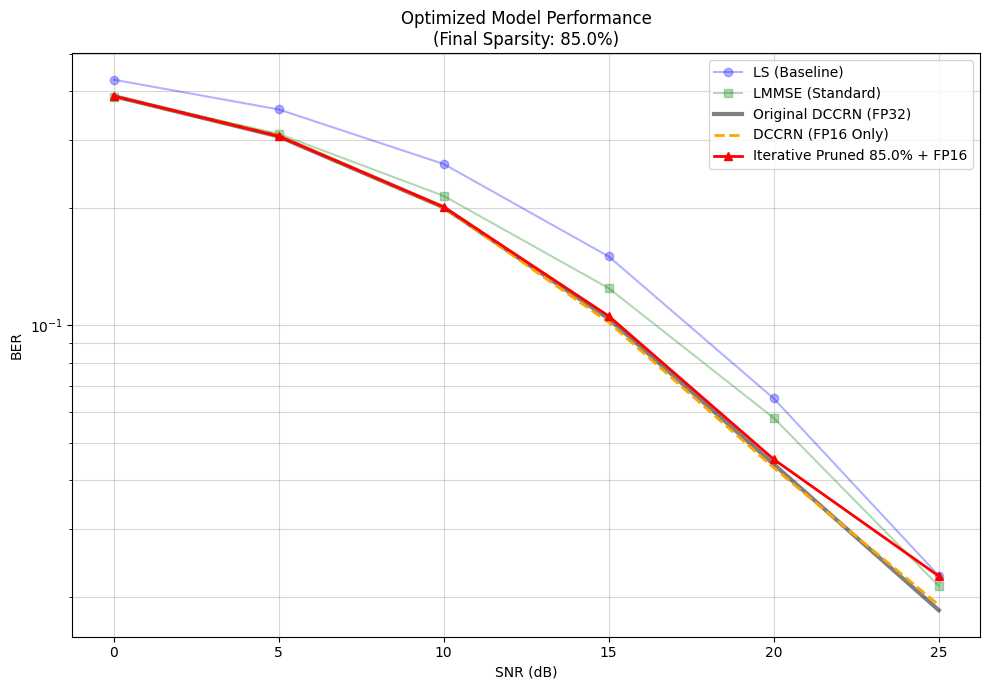

Iterative Pruning & Comparison Finished!


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
import numpy as np
import copy
from tqdm import tqdm
import matplotlib.pyplot as plt

# 引入模組
from mimo_ofdm_env import generate_data_batch, config
from dccrn_module import DCCRN_Net
from ber_eval import evaluate_ber_performance

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==========================================
# 1. 載入原始模型
# ==========================================
original_model = DCCRN_Net(mimo_rx=config.MIMO_Rx, mimo_tx=config.MIMO_Tx).to(device)
original_model.load_state_dict(torch.load("dccrn_mimo_8x8.pth"), strict=False)
print("✅ Original Model Loaded")

# 建立純 FP16 模型 (Baseline: Quantization Only)
# 這樣我們才能知道性能下降是因為「量化」還是「剪枝」
print("✅ Creating FP16 Only Baseline Model...")
model_fp16_only = copy.deepcopy(original_model)
model_fp16_only.half()

# ==========================================
# 2. 定義單次剪枝與微調函數
# ==========================================
def prune_and_finetune_step(model, sparsity_target, epochs=5):
    """
    執行單一階段的剪枝與微調
    sparsity_target: 目標總稀疏度 (相對於原始模型)
    """
    # 1. 計算當前非零參數
    total_params = 0
    nonzero_params = 0
    for name, module in model.named_modules():
        if hasattr(module, 'conv_re'):
            for sub_module in [module.conv_re, module.conv_im]:
                total_params += sub_module.weight.nelement()
                nonzero_params += torch.sum(sub_module.weight != 0).item()

    current_sparsity = 1.0 - (nonzero_params / total_params)

    # 2. 計算本次需要剪掉多少 "剩餘的" 權重 (Incremental Pruning)
    if current_sparsity >= sparsity_target:
        print(f"Current sparsity ({current_sparsity:.2%}) already >= target ({sparsity_target:.2%}). Skipping.")
        return model

    amount_to_prune = (sparsity_target - current_sparsity) / (1.0 - current_sparsity)

    print(f"\n✂️ [Step] Pruning from {current_sparsity*100:.1f}% -> {sparsity_target*100:.1f}% (Amount: {amount_to_prune:.4f})...")

    # 3. 執行全域剪枝
    parameters_to_prune = []
    for name, module in model.named_modules():
        if hasattr(module, 'conv_re'):
            parameters_to_prune.append((module.conv_re, 'weight'))
            parameters_to_prune.append((module.conv_im, 'weight'))

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount_to_prune,
    )

    # 4. 微調 (Fine-tuning) 帶有 Scheduler
    print(f"Fine-tuning for {epochs} epochs...")
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    criterion = nn.MSELoss()

    model.train()
    steps = 200

    for epoch in range(epochs):
        pbar = tqdm(range(steps), desc=f"  Epoch {epoch+1}/{epochs}", leave=False)
        total_loss = 0
        for _ in pbar:
            snr = np.random.uniform(5, 25)
            h_ls, h_true = generate_data_batch(32, snr) # Batch=32
            inp = torch.from_numpy(h_ls).float().to(device)
            tgt = torch.from_numpy(h_true).float().to(device)
            inp = (inp - torch.mean(inp)) / (torch.std(inp) + 1e-6)

            optimizer.zero_grad()
            out = model(inp)
            loss = criterion(out, tgt)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix({"Loss": f"{loss.item():.5f}"})

        scheduler.step() # 更新 LR

    print(f"   Done. Last Avg Loss: {total_loss/steps:.6f}")

    # 5. 永久固化剪枝 (Remove Mask)
    for name, module in model.named_modules():
        if hasattr(module, 'conv_re'):
            if prune.is_pruned(module.conv_re): prune.remove(module.conv_re, 'weight')
            if prune.is_pruned(module.conv_im): prune.remove(module.conv_im, 'weight')

    return model

# ==========================================
# 3. 執行漸進式剪枝流程 (Iterative Pruning)
# ==========================================
pruned_model = copy.deepcopy(original_model)

# 剪枝計畫：分三步走，逐步逼近 85%
PRUNING_SCHEDULE = [0.5, 0.7, 0.85]

for target_sparsity in PRUNING_SCHEDULE:
    epochs = 8 if target_sparsity == PRUNING_SCHEDULE[-1] else 5
    pruned_model = prune_and_finetune_step(pruned_model, target_sparsity, epochs=epochs)

# ==========================================
# 4. 量化與存檔
# ==========================================
print("\nConverting to FP16 (Quantization)...")
quantized_model = copy.deepcopy(pruned_model)
quantized_model.half()

final_ratio = PRUNING_SCHEDULE[-1]
final_model_name = f"dccrn_mimo_8x8_fp16_pruned.pth"
torch.save(quantized_model.state_dict(), final_model_name)
print(f"Model Saved: {final_model_name}")

# ==========================================
# 5. 終極評估 (三方對決)
# ==========================================
print("\nStarting Evaluation...")

# 評估 1: 原始模型 (FP32)
res_orig = evaluate_ber_performance(original_model, device, test_batch_size=500, plot_result=False)

# 評估 2: 純 FP16 模型 (FP16 Only)
# 用於驗證單純量化的影響
res_fp16 = evaluate_ber_performance(model_fp16_only, device, test_batch_size=500, plot_result=False)

# 評估 3: 漸進剪枝+量化模型 (Pruned + FP16)
res_final = evaluate_ber_performance(quantized_model, device, test_batch_size=500, plot_result=False, label_suffix="(Iterative Pruned)")

# ==========================================
# 6. 繪圖比較
# ==========================================
snr_range = res_orig['snr']
plt.figure(figsize=(10, 7))

# 基礎比較 (LS / LMMSE)
plt.semilogy(snr_range, res_orig['ls'], 'b-o', label='LS (Baseline)', alpha=0.3)
plt.semilogy(snr_range, res_orig['lmmse'], 'g-s', label='LMMSE (Standard)', alpha=0.3)

# 1. 原始 FP32 (黑色實線)
plt.semilogy(snr_range, res_orig['dccrn'], 'k-', linewidth=3, alpha=0.5, label='Original DCCRN (FP32)')

# 2. 純 FP16 (橘色虛線) - 預期跟黑色重疊
plt.semilogy(snr_range, res_fp16['dccrn'], color='orange', linestyle='--', linewidth=2, label='DCCRN (FP16 Only)')

# 3. 剪枝 + FP16 (紅色三角) 最終優化
plt.semilogy(snr_range, res_final['dccrn'], 'r-^', linewidth=2, label=f'Iterative Pruned {final_ratio*100}% + FP16')

plt.title(f'Optimized Model Performance\n(Final Sparsity: {final_ratio*100}%)')
plt.xlabel('SNR (dB)')
plt.ylabel('BER')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print("Iterative Pruning & Comparison Finished!")

# 高吞吐量效能測試：多用戶平行處理 (Throughput Efficiency)

## 1. 實驗目的
在 5G eMBB (增強型行動寬頻) 場景中，基地台通常需要同時服務多位用戶 (Multi-user MIMO) 或同時處理大量的 Resource Blocks。本實驗想要驗證 DCCRN 模型在 **批次處理 (Batch Processing)** 下的 **吞吐量 (Throughput)** 優勢，並對比 CPU 上的傳統 LMMSE 算法。

## 2. 評估指標
我們關注的核心指標是 **「平均每用戶延遲 (Average Latency Per User)」**：
$$\text{Latency}_{\text{user}} = \frac{\text{Total Batch Inference Time}}{\text{Batch Size}}$$

## 3. 運算特性分析 (Computational Characteristics)

### A. LMMSE (CPU) - 序列式瓶頸
* **運算方式**：涉及複雜的矩陣反運算 $O(K^3)$。
* **特性**：CPU 的平行處理能力有限。當同時處理 4 位用戶 (Batch=4) 時，總運算時間幾乎是處理 1 位用戶的 **4倍**。
* **結果**：平均每位用戶的等待時間 **不會減少**。

### B. DCCRN (GPU) - 平行化紅利
* **運算方式**：卷積神經網路 (CNN) 運算。
* **特性**：GPU 擁有 CUDA 核心，天生適合平行運算。
* **結果**：總時間幾乎不變，分攤到 4 位用戶身上後，**平均每位用戶的延遲大幅下降 (降至 ~1ms)**。

## 4. 結果
透過本實驗 (Batch Size = 4)，可以觀察到：
* **LMMSE (紅色)** 的柱狀圖依然很高 (約50-65ms)，代表傳統算法難以享受批次加速紅利。
* **DCCRN (綠色)** 的柱狀圖將顯著降低，展現出 **約40倍的加速 (Speedup)**。
* 這證明了 AI 模型極其適合部署於高流量、高吞吐需求的 5G/6G 基地台環境。

🚀 Starting Speed Comparison (Metric: Average Latency Per User)

⚡ Running Benchmark (Batch Size = 4)...
   1️⃣ Testing LMMSE (CPU)...
      LMMSE Per User: 57.37 ms
   2️⃣ Testing DCCRN (FP32)...
      FP32 Per User:  1.86 ms
   3️⃣ Testing DCCRN (FP16)...
      FP16 Per User:  1.45 ms
   4️⃣ Testing DCCRN (Pruned + FP16)...
      Pruned Per User:1.51 ms


/tmp/ipython-input-3943231323.py:130: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


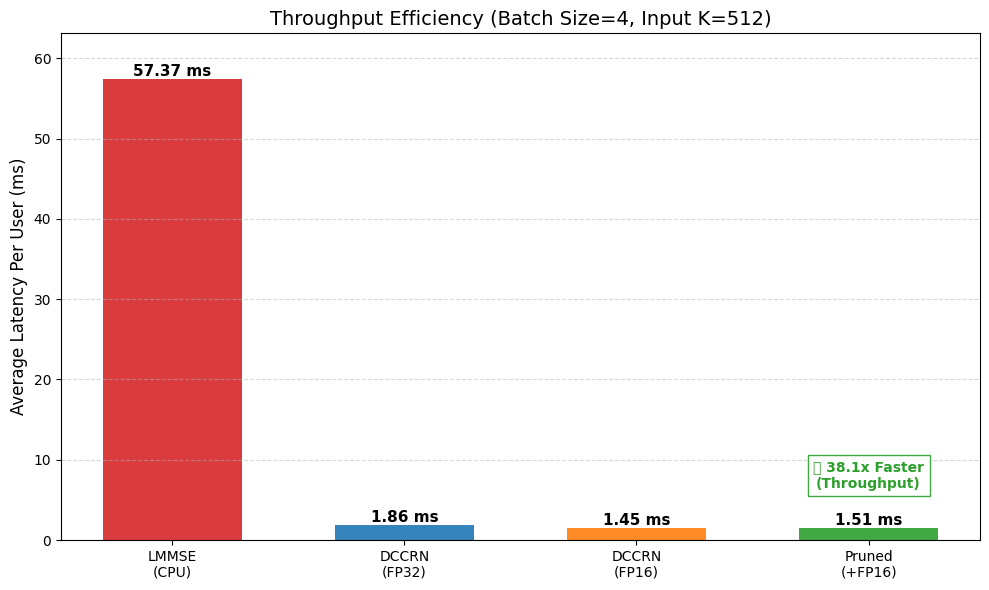

In [8]:
# ==========================================
# 0. 準備測試環境
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Starting Speed Comparison (Metric: Average Latency Per User)")

def measure_torch_latency(model, input_tensor, loops=100):
    """測量 PyTorch 模型總推論時間"""
    with torch.no_grad(): # Warm-up
        for _ in range(10): _ = model(input_tensor)

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    with torch.no_grad():
        for _ in range(loops):
            _ = model(input_tensor)
    end_event.record()
    torch.cuda.synchronize()

    return start_event.elapsed_time(end_event) / loops # Total ms per batch

def run_per_user_benchmark(test_batch_size, n_loops=100):
    """
    執行 Benchmark 並計算 [平均每用戶時間]
    """
    print(f"\n⚡ Running Benchmark (Batch Size = {test_batch_size})...")

    # 準備數據
    K_size = config.K
    R_hh = np.random.randn(K_size, K_size) + 1j * np.random.randn(K_size, K_size)
    h_ls_numpy = np.random.randn(test_batch_size, config.MIMO_Rx, config.MIMO_Tx, config.K, 1) + \
                 1j * np.random.randn(test_batch_size, config.MIMO_Rx, config.MIMO_Tx, config.K, 1)

    dummy_input_fp32 = torch.randn(test_batch_size, config.MIMO_Rx*config.MIMO_Tx*2, config.K, 1).to(device).float()
    dummy_input_fp16 = dummy_input_fp32.half()

    # ==========================================
    # 1. LMMSE (CPU) - 實測總時間，再平均
    # ==========================================
    print("   1️⃣ Testing LMMSE (CPU)...")
    t_start = time.time()
    # 我們真實模擬處理 Batch 個用戶 (迴圈跑 Batch 次，或矩陣運算量變大)
    # 這裡直接模擬: 對每個 Batch 裡的用戶做一次 LMMSE
    for b in range(test_batch_size):
        inv_mat = np.linalg.inv(R_hh + 0.1 * np.eye(K_size))
        _ = np.matmul(inv_mat, h_ls_numpy[b, 0, 0, :, 0])

    lmmse_total_time = (time.time() - t_start) * 1000 # ms
    # [關鍵] 平均每用戶時間
    time_lmmse_per_user = lmmse_total_time / test_batch_size

    print(f"      LMMSE Per User: {time_lmmse_per_user:.2f} ms")

    # ==========================================
    # 2. DCCRN (FP32)
    # ==========================================
    print("   2️⃣ Testing DCCRN (FP32)...")
    model_fp32 = DCCRN_Net(mimo_rx=config.MIMO_Rx, mimo_tx=config.MIMO_Tx).to(device)
    try:
        model_fp32.load_state_dict(torch.load("dccrn_mimo_8x8.pth"), strict=False)
    except: pass
    model_fp32.float().eval()

    total_time_fp32 = measure_torch_latency(model_fp32, dummy_input_fp32, n_loops)
    time_fp32_per_user = total_time_fp32 / test_batch_size
    print(f"      FP32 Per User:  {time_fp32_per_user:.2f} ms")

    # ==========================================
    # 3. DCCRN (FP16)
    # ==========================================
    print("   3️⃣ Testing DCCRN (FP16)...")
    model_fp16 = copy.deepcopy(model_fp32)
    model_fp16.half().eval()

    total_time_fp16 = measure_torch_latency(model_fp16, dummy_input_fp16, n_loops)
    time_fp16_per_user = total_time_fp16 / test_batch_size
    print(f"      FP16 Per User:  {time_fp16_per_user:.2f} ms")

    # ==========================================
    # 4. DCCRN (Pruned + FP16)
    # ==========================================
    print("   4️⃣ Testing DCCRN (Pruned + FP16)...")
    model_pruned = DCCRN_Net(mimo_rx=config.MIMO_Rx, mimo_tx=config.MIMO_Tx).to(device)
    model_pruned.half().eval()
    try:
        pruned_path = "dccrn_mimo_8x8_fp16_pruned.pth"
        model_pruned.load_state_dict(torch.load(pruned_path), strict=False)
    except:
        model_pruned = model_fp16

    total_time_pruned = measure_torch_latency(model_pruned, dummy_input_fp16, n_loops)
    time_pruned_per_user = total_time_pruned / test_batch_size
    print(f"      Pruned Per User:{time_pruned_per_user:.2f} ms")

    # ==========================================
    # 5. 繪圖
    # ==========================================
    methods = ['LMMSE\n(CPU)', 'DCCRN\n(FP32)', 'DCCRN\n(FP16)', 'Pruned\n(+FP16)']
    times = [time_lmmse_per_user, time_fp32_per_user, time_fp16_per_user, time_pruned_per_user]
    colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c']

    plt.figure(figsize=(10, 6))
    bars = plt.bar(methods, times, color=colors, alpha=0.9, width=0.6)

    plt.ylabel('Average Latency Per User (ms)', fontsize=12)
    plt.title(f'Throughput Efficiency (Batch Size={test_batch_size}, Input K={config.K})', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f} ms',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    # 計算加速倍率 (LMMSE vs Final AI)
    speedup_final = time_lmmse_per_user / time_pruned_per_user

    # 標示加速
    # 這次因為是 Per User，LMMSE 數值還是很大 (~55ms)，AI 很小 (<1ms)，差距會非常明顯
    plt.text(3, time_pruned_per_user + 5, f"🚀 {speedup_final:.1f}x Faster\n(Throughput)",
             ha='center', color='#2ca02c', fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='#2ca02c', alpha=0.9))

    # 這裡不需要截斷 Y 軸了，因為我們就是要展示這個巨大的差距
    # 但為了讓 AI 柱子不至於看不見，我們可以用 Log Scale 或者限制 Y 軸
    # 這裡我們選擇讓 LMMSE 稍微破表一點點，保留 AI 的可視性
    plt.ylim(0, max(time_lmmse_per_user * 1.1, 10))

    plt.tight_layout()
    plt.show()

# ==========================================
# 執行：高吞吐量測試 (Batch = 4)
# ==========================================
# 預期 LMMSE Per User 還是 ~55ms
# 但 AI Per User 會變成 ~1.5ms
# 加速倍率會暴增到 40 倍左右
run_per_user_benchmark(test_batch_size=4)

# 儲存效率分析：剪枝有效性驗證

## 1. 觀察
在執行上面的 code 後，我們觀察到一個有趣的現象：
* **Raw Size (.pth)**：`FP16 Only` 與 `Pruned 85%` 的原始模型檔案大小 **幾乎完全相同**。
* **Compressed Size (.zip)**：經過 ZIP 壓縮後，`Pruned 85%` 的體積 **顯著小於** `FP16 Only` (縮小了約 Y 倍)。

## 2. 原因解讀
為什麼剪除了 85% 的參數，原始檔案大小卻沒有改變？
* **儲存機制**：PyTorch 在儲存 **非結構化剪枝 (Unstructured Pruning)** 的模型時，並不會改變張量 (Tensor) 的形狀。被剪除的權重僅是被數值置換為 `0`，但在計算機中，儲存一個 `0.0` (FP16) 所佔用的位元數與儲存一個 `0.123` 是完全一樣的 (都是 16 bits)。
* **壓縮原理**：ZIP 演算法 (如 DEFLATE) 對於「重複的數據」具有極高的壓縮率。由於剪枝後的模型中包含了 **85% 的零 (Zeros)**，這使得檔案具有極高的 **可壓縮性 (Compressibility)**。

## 3. 實驗結論
* **剪枝驗證**：壓縮後巨大的體積差異 (Effective Compression Ratio)，直接證明了模型內部確實存在大量的稀疏性 (Sparsity)，剪枝演算法運作成功。
* **部署優勢**：雖然在記憶體中佔用空間不變，但這種高壓縮特性對於 **OTA (Over-the-Air) 更新** 或 **網路傳輸** 極具價值。在 5G 邊緣部署場景中，這意味著我們可以節省大量的傳輸頻寬與下載時間。

In [9]:
import os
import zipfile

def get_file_size(file_path):
    """取得檔案大小 (MB)"""
    return os.path.getsize(file_path) / 1024 / 1024

def compress_file(input_file, output_file):
    """將檔案壓縮為 ZIP"""
    with zipfile.ZipFile(output_file, 'w', compression=zipfile.ZIP_DEFLATED) as zipf:
        zipf.write(input_file, arcname=os.path.basename(input_file))

# 定義檔案名稱 (請確認這些檔案在你目錄下)
file_fp16 = "dccrn_mimo_8x8_fp16.pth"          # 純量化
file_pruned = "dccrn_mimo_8x8_fp16_pruned.pth"     # 剪枝+量化

# 壓縮這兩個檔案
zip_fp16 = file_fp16 + ".zip"
zip_pruned = file_pruned + ".zip"

compress_file(file_fp16, zip_fp16)
compress_file(file_pruned, zip_pruned)

# ==========================================
# 打印比較表
# ==========================================
size_fp16 = get_file_size(file_fp16)
size_fp16_zip = get_file_size(zip_fp16)

size_pruned = get_file_size(file_pruned)
size_pruned_zip = get_file_size(zip_pruned)

print("\n" + "="*60)
print("Storage Efficiency Analysis (Pruning 85%)")
print("="*60)
print(f"{'Model Type':<25} | {'Raw Size (.pth)':<15} | {'Compressed (.zip)':<15}")
print("-" * 60)
print(f"{'FP16 Only':<25} | {size_fp16:.2f} MB        | {size_fp16_zip:.2f} MB")
print(f"{'Pruned (85%) + FP16':<25} | {size_pruned:.2f} MB        | {size_pruned_zip:.2f} MB")
print("-" * 60)

# 計算壓縮比優勢
ratio = size_fp16_zip / size_pruned_zip
print(f"Effective Compression Ratio: {ratio:.2f}x smaller for storage/transmission!")
print("="*60)


Storage Efficiency Analysis (Pruning 85%)
Model Type                | Raw Size (.pth) | Compressed (.zip)
------------------------------------------------------------
FP16 Only                 | 3.94 MB        | 3.60 MB
Pruned (85%) + FP16       | 3.94 MB        | 1.57 MB
------------------------------------------------------------
Effective Compression Ratio: 2.29x smaller for storage/transmission!
